# Notebook Introduction

Consider the Lotka-Volterra equations for a predator-prey dynamics:

$$
\begin{align}
& \dot x = \alpha x - \gamma xy \\
& \dot y = -\beta y + \eta (\gamma xy)
\end{align}
$$

Suppose we only know $\alpha, \beta$ and $\eta$, how can we approximate the term $\gamma xy$? In this case we will use and implement the *Universal Differential Equations* according to [1] in Python.

In particular, we will:
1. Generate a synthetic dataset by fixing the parameters first
2. Consider the L-V equations only with $\alpha, \beta, \eta$ known; the term $\gamma xy$ will be approximated with a Neural Network defined as $\texttt{NN}(\theta, t)$
3. Train the Neural Network with the method described in the paper, in particular using numerical integration of ODEs (Newton's first-order method) 

The loss used to train the NN will be the MSE loss, defined as 

$$
\mathcal L_{\texttt{MSE} }(\theta) := \frac{1}{N} \sum_{i = 1, \ldots, n} [(\hat x_\theta(t_i) - x_i)^2 + (\hat y_\theta(t_i) - y_i)^2]
$$

Where $\hat x_\theta, \hat y_\theta$ are the solutions of the following parametrised DE in a certain time interval $[0, T]$:

$$
\begin{align}
& \dot x = \alpha x - \texttt{NN}(\theta, t)[1] \\
& \dot y = -\beta y + \cdot \texttt{NN}(\theta, t)[0]
\end{align}
$$


> *Remark.* Our approach will differ from [1] as we will approximate the term $\gamma xy$ with *only one* neural network, instead of two. We consider this approach to be better and leverage our knowledge of the system further.

Moreover the neural network will have two inputs and two outputs, one for each component of the dynamical system.

**In this alternative version, we will consider the anti-dimensionalised version of the Lotka-Volterra dynamics defined as follows:**

$$
\begin{align}
& \dot x = x(1-y) \\
& \dot y = cy(x-1)
\end{align}
$$

And thus we will have the following UDE proposed:

$$
\begin{align}
& \dot x = 2x-NN(x,y)[0] \\
& \dot y = c(NN(x,y)[1]) - 3y
\end{align}
$$


And we will see how results vary by setting $c<1$ and $c>1$


In the end, we will compare the results with the ones presented in the paper.

In [47]:
# Libraries
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from torch import nn, optim 
import torch
from torchdiffeq import odeint
import pysindy as ps

if torch.cuda.is_available():
    device = "cuda:0"

else:
    device ="cpu"

device="cpu"

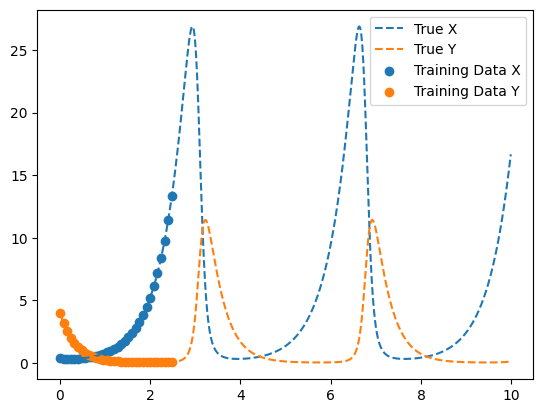

In [48]:
# Part 1: Synthetic Data Generation
c = 0.5

def lotka_volterra(t, data, c):
    x = data[0]
    y = data[1]
    return np.array([2*x - x*y, 
                    -3*y + c*x*y])

x0 = (0.4, 4)

sol = solve_ivp(lotka_volterra, t_span = [0, 10], t_eval=np.arange(0, 10, 0.01), args=(c,), y0 = x0, rtol=1e-9, atol=1e-9)
data = sol.y

T = sol.t
X = data[0]
Y = data[1]

plt.plot(T, X, "--", label="True X")
plt.plot(T, Y, "--", label="True Y")

T_train = T[:250:8]
X_train = X[:250:8]
Y_train = Y[:250:8]

plt.scatter(T_train, X_train, label="Training Data X")
plt.scatter(T_train, Y_train, label="Training Data Y")

plt.legend()

plt.show()




In [114]:
# Define UDE

class universal_LV(nn.Module):
    def __init__(self, a, b):
        super().__init__()
        self.a = a 
        self.b = b

        self.scale_net = torch.tensor([-1., 1], device=device)
        self.scale_dynamics = torch.tensor([a, -b], dtype=torch.float32, device=device)

        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.SiLU(),
            nn.Linear(16, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 16), 
            nn.SiLU(),
            nn.Linear(16, 2),
            nn.Linear(2,1),
            nn.Linear(1,2)
        ) 

    def forward(self, t, data):
        out_net = self.net(data)
        out_net *= self.scale_net

        summ = data * self.scale_dynamics
        return out_net + summ
    
class neural_LV(nn.Module):
    # other case: full NN approach
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.SiLU(),
            nn.Linear(16, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 16), 
            nn.SiLU(),
            nn.Linear(16, 2)
        ) 

    def forward(self, t, data):
        return self.net(data)


In [115]:
# Train UDE network to training data
my_lv = universal_LV(2, 3)
my_lv = my_lv.to(device)

from tqdm import tqdm 

lr = 0.005
optimizer = torch.optim.Adam(my_lv.parameters(), lr)

x0_torch = torch.tensor(x0, dtype=torch.float32).to(device)
T_train_torch = torch.tensor(T_train, dtype=torch.float32).to(device)
Y_train_torch = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_train_torch = torch.tensor(X_train, dtype=torch.float32).to(device)

for EPOCH in (range(1, 2500)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(my_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='dopri5')

    # calculate loss
    loss_norm = torch.mean((info - torch.stack([X_train_torch, Y_train_torch], dim=1)) ** 2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 1: MSE Loss (L2 norm)= 1.197E-01
Epoch 2: MSE Loss (L2 norm)= 2.593E-02
Epoch 3: MSE Loss (L2 norm)= 5.838E-02
Epoch 4: MSE Loss (L2 norm)= 7.262E-02
Epoch 5: MSE Loss (L2 norm)= 4.942E-02
Epoch 6: MSE Loss (L2 norm)= 2.756E-02
Epoch 7: MSE Loss (L2 norm)= 2.503E-02
Epoch 8: MSE Loss (L2 norm)= 3.573E-02
Epoch 9: MSE Loss (L2 norm)= 4.349E-02
Epoch 10: MSE Loss (L2 norm)= 4.057E-02
Epoch 11: MSE Loss (L2 norm)= 3.110E-02
Epoch 12: MSE Loss (L2 norm)= 2.325E-02
Epoch 13: MSE Loss (L2 norm)= 2.197E-02
Epoch 14: MSE Loss (L2 norm)= 2.611E-02
Epoch 15: MSE Loss (L2 norm)= 3.036E-02
Epoch 16: MSE Loss (L2 norm)= 3.052E-02
Epoch 17: MSE Loss (L2 norm)= 2.664E-02
Epoch 18: MSE Loss (L2 norm)= 2.198E-02
Epoch 19: MSE Loss (L2 norm)= 1.971E-02
Epoch 20: MSE Loss (L2 norm)= 2.061E-02
Epoch 21: MSE Loss (L2 norm)= 2.290E-02
Epoch 22: MSE Loss (L2 norm)= 2.406E-02
Epoch 23: MSE Loss (L2 norm)= 2.296E-02
Epoch 24: MSE Loss (L2 norm)= 2.049E-02
Epoch 25: MSE Loss (L2 norm)= 1.843E-02
Epoch 26:

KeyboardInterrupt: 

In [116]:
# Train neural ODE network to training data
my_neural_lv = neural_LV()
my_neural_lv = my_neural_lv.to(device)

from tqdm import tqdm 

lr = 0.005
n_optimizer = torch.optim.Adam(my_neural_lv.parameters(), lr)

x0_torch = torch.tensor(x0, dtype=torch.float32).to(device)
T_train_torch = torch.tensor(T_train, dtype=torch.float32).to(device)
Y_train_torch = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_train_torch = torch.tensor(X_train, dtype=torch.float32).to(device)

for EPOCH in (range(1, 2500)):
    n_optimizer.zero_grad()

    # get forward solution
    info = odeint(my_neural_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='rk4')

    # calculate loss
    loss_norm = torch.mean((info - torch.stack([X_train_torch, Y_train_torch], dim=1)) ** 2)
    loss_norm.backward()

    n_optimizer.step()

    with torch.no_grad():
        
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 1: MSE Loss (L2 norm)= 1.583E+01
Epoch 2: MSE Loss (L2 norm)= 1.553E+01
Epoch 3: MSE Loss (L2 norm)= 1.523E+01
Epoch 4: MSE Loss (L2 norm)= 1.492E+01
Epoch 5: MSE Loss (L2 norm)= 1.456E+01
Epoch 6: MSE Loss (L2 norm)= 1.414E+01
Epoch 7: MSE Loss (L2 norm)= 1.363E+01
Epoch 8: MSE Loss (L2 norm)= 1.301E+01
Epoch 9: MSE Loss (L2 norm)= 1.225E+01
Epoch 10: MSE Loss (L2 norm)= 1.136E+01
Epoch 11: MSE Loss (L2 norm)= 1.034E+01
Epoch 12: MSE Loss (L2 norm)= 9.223E+00
Epoch 13: MSE Loss (L2 norm)= 8.039E+00
Epoch 14: MSE Loss (L2 norm)= 6.844E+00
Epoch 15: MSE Loss (L2 norm)= 5.698E+00
Epoch 16: MSE Loss (L2 norm)= 4.716E+00
Epoch 17: MSE Loss (L2 norm)= 4.197E+00
Epoch 18: MSE Loss (L2 norm)= 4.546E+00
Epoch 19: MSE Loss (L2 norm)= 4.914E+00
Epoch 20: MSE Loss (L2 norm)= 4.587E+00
Epoch 21: MSE Loss (L2 norm)= 4.056E+00
Epoch 22: MSE Loss (L2 norm)= 3.678E+00
Epoch 23: MSE Loss (L2 norm)= 3.507E+00
Epoch 24: MSE Loss (L2 norm)= 3.479E+00
Epoch 25: MSE Loss (L2 norm)= 3.523E+00
Epoch 26:

KeyboardInterrupt: 

In [117]:
pred = odeint(my_lv, x0_torch, T_train_torch, method='dopri5', atol=1e-5, rtol=1e-5)
pred_neural = odeint(my_neural_lv, x0_torch, T_train_torch)

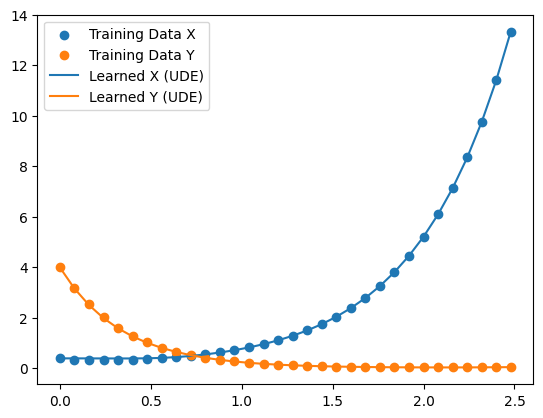

In [118]:
plt.scatter(T_train, X_train,label="Training Data X")
plt.scatter(T_train, Y_train,label="Training Data Y")

plt.plot(T_train, pred[:, 0].cpu().detach().numpy(), label="Learned X (UDE)")
plt.plot(T_train, pred[:, 1].cpu().detach().numpy(), label="Learned Y (UDE)")

plt.legend()

plt.show()


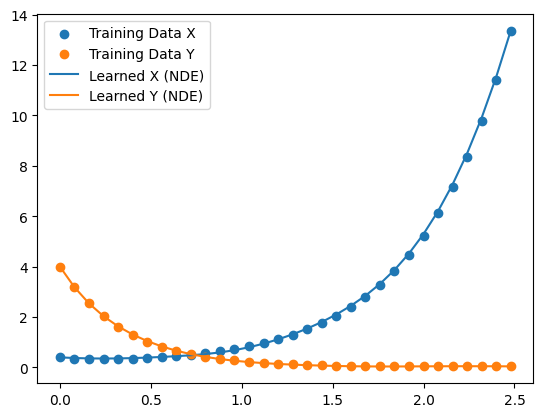

In [119]:
plt.scatter(T_train, X_train,label="Training Data X")
plt.scatter(T_train, Y_train,label="Training Data Y")

plt.plot(T_train, pred_neural[:, 0].cpu().detach().numpy(), label="Learned X (NDE)")
plt.plot(T_train, pred_neural[:, 1].cpu().detach().numpy(), label="Learned Y (NDE)")

plt.legend()

plt.show()


In [120]:
# Train SINDy with the known derivatives now!
# UDEs

pred_new = odeint(my_lv, torch.tensor(x0, dtype=torch.float32), teval:=torch.arange(0, 2.5, 0.01))
pred_new_np = pred_new.detach().numpy()

T_train_ps = teval.detach().numpy()
X_train_ps = pred_new_np[:, 0]
Y_train_ps = pred_new_np[:, 1]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ(0.25)
)

X_dot = np.zeros((T_train_ps.shape[0], 2))

for i,(t,x, y) in enumerate(zip(T_train_ps, X_train_ps, Y_train_ps)):
    X_dot[i, :] = my_lv(
        torch.tensor([t], dtype=torch.float32),
        torch.tensor([x, y], dtype=torch.float32)
    ).detach().numpy()

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

(x)' =  1.993 x + -0.836 x y
(y)' = -3.053 y +  0.426 x y


In [127]:
# do the same thing with NDE
pred_new = odeint(my_neural_lv, torch.tensor(x0, dtype=torch.float32), teval:=torch.arange(0, 3, 0.001))
pred_new_np = pred_new.detach().numpy()

T_train_ps = teval.detach().numpy()
X_train_ps = pred_new_np[:, 0]
Y_train_ps = pred_new_np[:, 1]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ()
)

X_dot = np.zeros((T_train_ps.shape[0], 2))

for i,(t,x, y) in enumerate(zip(T_train_ps, X_train_ps, Y_train_ps)):
    X_dot[i, :] = my_lv(
        torch.tensor([t], dtype=torch.float32),
        torch.tensor([x, y], dtype=torch.float32)
    ).detach().numpy()

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

(x)' =  1.972 x + -0.678 y + -0.187 x y +  0.429 y^2 + -0.731 x y^2
(y)' = -2.684 y + -0.904 y^2 +  2.161 x y^2 +  0.234 y^3 + -0.604 x y^3


In [128]:
# What if we trained SINDy without UDE-enhanched derivatives

sol = solve_ivp(lotka_volterra, t_span = [0, 20], t_eval=np.arange(0, 20, 0.01), args= (1.25,), y0 = x0, rtol=1e-9, atol=1e-9)
data = sol.y

T = sol.t
X = data[0]
Y = data[1]

T_train_ps = T[:200:7]
X_train_ps = X[:200:7]
Y_train_ps = Y[:200:7]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ(0.2)
)

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    # x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

(x)' =  2.002 x + -0.997 x y
(y)' = -3.007 y +  1.256 x y


In [22]:
# plotl earned dynamics

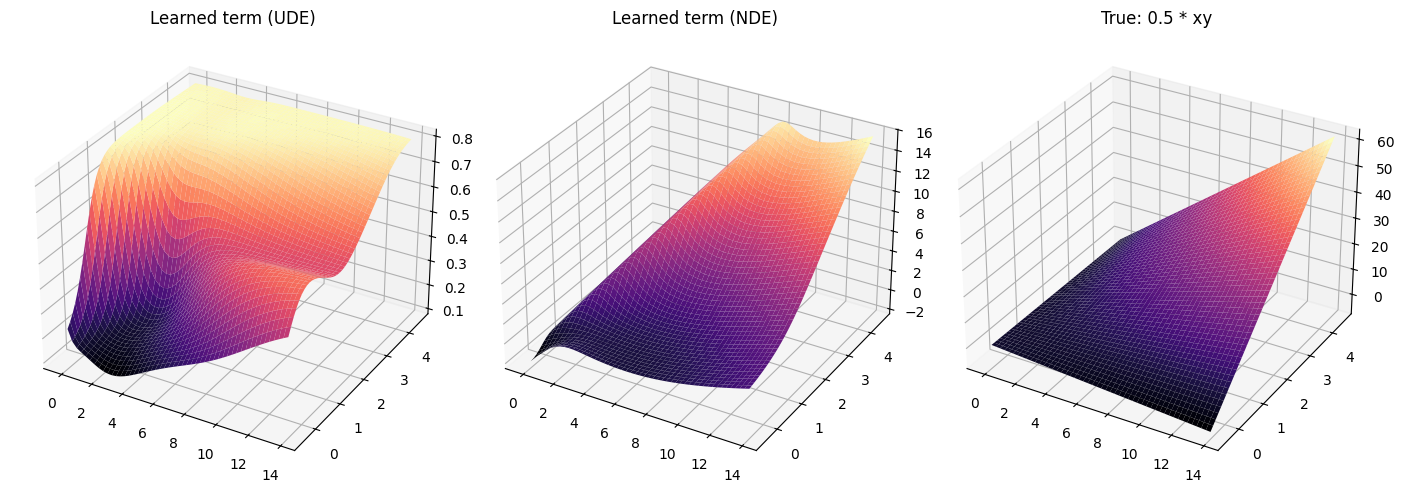

In [123]:
x_min, x_max = X_train.min() - 0.5, X_train.max() + 0.5
y_min, y_max = Y_train.min() - 0.5, Y_train.max() + 0.5

x = np.linspace(x_min, x_max, 50)
y = np.linspace(y_min, y_max, 50)
X, Y = np.meshgrid(x, y)

# Feed grid through NN
punti_input = np.stack([X.ravel(), Y.ravel()], axis=-1)
input_tensor = torch.tensor(punti_input, dtype=torch.float32)

with torch.no_grad():
    z_pred = my_lv.net(input_tensor)[:, 0]  # Take first output
    Z_nn = z_pred.reshape(X.shape).numpy()
    z_ude_pred = my_neural_lv(0, input_tensor)[:, 0]
    Z_ude_nn = - z_ude_pred.reshape(X.shape).numpy() + 2 * X # transformation into what should be the beta * x * y term

# True function: -beta*x*y (where beta=0.9)
Z_true = X * Y

fig = plt.figure(figsize=(14, 5))

# Plot UDE
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, Z_nn, cmap='magma', edgecolor='none')
ax1.set_title('Learned term (UDE)')

# Plot NDE 
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X, Y, Z_ude_nn, cmap='magma', edgecolor='none')
ax2.set_title('Learned term (NDE)')

# Plot NDE 
ax2 = fig.add_subplot(133, projection='3d')
ax2.plot_surface(X, Y, Z_true, cmap='magma', edgecolor='none')
ax2.set_title('True: 0.5 * xy')


plt.tight_layout()
plt.show()

In [130]:
torch.save(my_lv.state_dict(), "my_lv_ude_weights_alt1.dinomeng")
torch.save(my_neural_lv.state_dict(), "my_lv_nde_weights_alt1.dinomeng")


# References

[1] C. Rackauckas et al., ‘Universal Differential Equations for Scientific Machine Learning’, Aug. 31, 2020, In Review. doi: 10.21203/rs.3.rs-55125/v1.
